### Cell 1 — Import the analysis libraries

**Why are we doing this?**

Every later step depends on tools for tables, numerical calculations, regression, and statistical inference. Importing them at the beginning makes the notebook reproducible and keeps the analysis organized.

**What are we doing?**

- `pandas` (`pd`) works with tabular data using DataFrames.
- `numpy` (`np`) provides numerical operations and values such as `NaN`.
- `LinearRegression` fits ordinary least-squares linear regression models.
- `statsmodels.api` (`sm`) provides regression results with t-statistics and p-values.

**How does it work?**

Python loads these libraries and assigns short names. Nothing is modeled yet; this cell only makes the functions available to later cells.

**Why did we choose this approach?**

These are common, well-tested Python tools for introductory data science. Scikit-learn is convenient for fitting and prediction, while statsmodels exposes statistical summaries that scikit-learn does not provide directly.

**Alternatives:**

A formula library such as `statsmodels.formula.api` could express the model more compactly. Pure NumPy could calculate regression coefficients, but it would require more manual linear algebra and would be easier to implement incorrectly.

**Key data science concepts:**

A library is reusable code written by others. An import makes that code available in the current Python session. Reproducibility means that someone else can run the same setup and obtain the same analysis.

**Potential issues / improvements:**

The imports will fail if the packages are not installed in the selected Python environment. For a shared project, package versions should be recorded in an environment file.

**Connection to the next step:**

The next cell uses pandas to read the first CSV data set into a DataFrame.

In [20]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import seaborn as sns

### Cell 2 — Load and preview the first data set

**Why are we doing this?**

The regression questions use `homework_1.1.csv`. Before modeling, we need to bring the data into Python and inspect a few rows so we can check that the file loaded and the columns look as expected.

**What are we doing?**

`pd.read_csv` reads comma-separated values into the DataFrame `df`. `df.head()` displays the first five rows without changing the data.

**How does it work?**

The file path identifies the input data. The resulting table should contain predictors `X1`, `X2`, and `X3`, plus the response variable `Y`. The preview is a quick structural check.

**Why did we choose this approach?**

CSV is a simple, portable tabular format, and pandas is designed for labeled columns and row operations. Previewing before analysis is a required quality check, not just presentation.

**Alternatives:**

`df.info()` would show data types and missing values, while `df.describe()` would summarize distributions. Those are useful follow-up checks when a data set is unfamiliar.

**Key data science concepts:**

A DataFrame is a labeled two-dimensional table. A feature or predictor is an input used to explain or predict an outcome; the target or response is the value being predicted.

**Potential issues / improvements:**

An absolute path works only on this computer. A relative path or configuration variable is more portable. Missing values, incorrect column names, or numeric columns stored as text should be checked before fitting a model.

**Connection to the next step:**

The next code cell selects `X1`, `X2`, and `X3` as predictors and `Y` as the target for multiple linear regression.

In [21]:
df =pd.read_csv('/Users/gaurav/workspace/datascience/boston_university/semester3/ms_datascience/data/homework_1.1.csv')
df.head()

,X1,X2,X3,Y
0,-0.440646,-0.390227,0.156718,-0.877671
1,-3.810099,-1.304665,-1.105117,-10.130388
2,-1.425451,-0.340049,1.115908,0.284068
3,-1.325750,0.161906,-0.254670,-1.994344
4,3.120263,1.487343,-1.164839,2.030030


For questions 1 to 3:

Perform a linear regression to predict Y from X1, X2, and X3. Use the file homework_1.1.csv.

Question 1
Which of the following is closest to the coefficient of X1? 

### Cell 3 — Prepare and fit the multiple regression model

**Why are we doing this?**

Question 1 asks how much `Y` changes with `X1` while also accounting for `X2` and `X3`. Multiple linear regression estimates these adjusted relationships in one model.

**What are we doing?**

`X` contains the three predictor columns and `y` contains the outcome. `LinearRegression()` creates a model, and `.fit(X, y)` estimates the intercept and one coefficient for each predictor.

**How does it work?**

The model has the form `Y = intercept + beta1*X1 + beta2*X2 + beta3*X3 + error`. Each coefficient describes the expected change in `Y` for a one-unit increase in that predictor while the other predictors are held fixed. `coef_` stores the slopes and `intercept_` stores the baseline value when predictors are zero.

**Why did we choose this approach?**

Ordinary least squares is appropriate for a continuous outcome and gives a direct answer to the coefficient question. Scikit-learn provides a simple, reliable fitting interface.

**Alternatives:**

Statsmodels OLS can fit the same model while providing a formal summary. Regularized models such as Ridge or Lasso can be useful when predictors are numerous or highly correlated, but their coefficients are intentionally shrunk and are not the same interpretation required here.

**Key data science concepts:**

A coefficient is a slope. Holding other variables fixed is called an adjusted or partial effect. The intercept is the predicted outcome when all predictors equal zero. The fitted model estimates associations; it does not automatically prove causation.

**Potential issues / improvements:**

The interpretation assumes a roughly linear relationship, independent observations, reasonably constant error variance, and limited problematic multicollinearity. A train/test split and residual diagnostics would be useful for prediction, although this quiz focuses on coefficient estimation.

**Connection to the next step:**

The fitted coefficients are reused as the multiple-regression values `beta` when they are compared with separate one-predictor regressions.

In [22]:
# Define features and target variable
X = df[['X1', 'X2', 'X3']]
y = df['Y']

# intializing the model

model = LinearRegression()
model.fit(X, y)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# Output coefficients
print("X1 Coefficient:", model.coef_[0])
print("X2 Coefficient:", model.coef_[1])
print("X3 Coefficient:", model.coef_[2])

Coefficients: [1.00713766 1.96456859 2.97548854]
Intercept: 0.002643003344473427
X1 Coefficient: 1.007137655075955
X2 Coefficient: 1.964568594871352
X3 Coefficient: 2.975488535143422


Which Xi has the greatest difference between the amount Y increases for each 1 unit of Xi (fixing the other Xi’s), as opposed to the amount that Y increases for each 1 unit of Xi in the dataset, on average (not fixing the other Xis)? Hint: for the former, you'll have to regress Y on Xi alone, while for the latter, you'll have to regress Y on all three Xis. 

### Cell 4 — Fit one simple regression for each predictor

**Why are we doing this?**

Question 2 compares two meanings of a coefficient: the adjusted change from the multiple model and the average one-predictor relationship in the data. Separate simple regressions provide the second quantity.

**What are we doing?**

`beta` stores the multiple-regression slopes. The loop takes one feature at a time, fits `Y` on that feature alone, and stores its slope in `alpha`.

**How does it work?**

For each feature, `df[[feature]]` remains a two-dimensional DataFrame, which is the shape expected by scikit-learn. The model estimates `Y = intercept + alpha_i*Xi + error`. The coefficient is printed so it can be compared later.

**Why did we choose this approach?**

Repeating the same operation in a loop avoids manually writing three nearly identical models and makes the comparison consistent across predictors.

**Alternatives:**

A loop using statsmodels formulas would also work. Correlations can describe the direction and strength of pairwise association, but correlation alone does not provide the same slope interpretation or intercept.

**Key data science concepts:**

A simple regression uses one predictor; a multiple regression uses several. A simple slope reflects both the relationship between a predictor and `Y` and any relationships that predictor has with omitted predictors.

**Potential issues / improvements:**

Differences between `alpha` and `beta` can result from correlated predictors, omitted-variable effects, or confounding. These slopes should not be interpreted as causal effects without a stronger study design.

**Connection to the next step:**

The dictionaries `alpha` and `beta` are compared in the following cell to identify the largest absolute difference.

In [23]:
beta = {'X1': model.coef_[0], 'X2': model.coef_[1], 'X3': model.coef_[2]}

# Simple linear regression model for each feature
alpha = {}
for feature in ['X1', 'X2', 'X3']:
    X_single = df[[feature]]
    model_single = LinearRegression()
    model_single.fit(X_single, y)
    alpha[feature] = model_single.coef_[0]
    print(f"Coefficient for {feature}: {alpha[feature]}")



Coefficient for X1: 1.8417610991715128
Coefficient for X2: 4.0836125794230185
Coefficient for X3: 3.0970412020437923


### Cell 5 — Compare adjusted and simple slopes

**Why are we doing this?**

The question asks which predictor changes most when the other predictors are accounted for. Computing the absolute difference gives a direct comparison of the two slope estimates.

**What are we doing?**

The formatted header labels the columns. For each feature, the code calculates `abs(beta[feature] - alpha[feature])` and prints both slopes plus their difference.

**How does it work?**

`beta` is the slope from the model using all predictors. `alpha` is the slope from the model using only the current predictor. `abs` removes the sign because the question asks for the greatest difference in size.

**Why did we choose this approach?**

A small table makes the comparison transparent and reduces the chance of selecting the wrong variable by looking at only one coefficient.

**Alternatives:**

The differences could be stored in a dictionary and selected with `max(..., key=...)`. A DataFrame would be better if the comparison grew to many variables or needed plotting.

**Key data science concepts:**

Comparing adjusted and unadjusted estimates helps reveal the role of relationships among predictors. A large difference is evidence that the predictor's standalone association is not the same as its partial association.

**Potential issues / improvements:**

The calculation compares slopes on their original scales. If predictors use very different units, standardized coefficients may be more appropriate for comparing relative importance, but standardization changes the interpretation.

**Connection to the next step:**

After answering the coefficient-difference question, the notebook uses statsmodels to assess statistical significance with t-statistics.

In [24]:
# Compare the differences between the coefficients from the multiple regression model and the simple regression models
print(f"{'Variable':<10} | {'Multiple (beta)':<15} | {'Simple (alpha)':<15} | {'Difference':<12}")
for feature in ['X1', 'X2', 'X3']:
    difference = abs(beta[feature] - alpha[feature])
    print(f"{feature:<10} | {beta[feature]:<15.4f} | {alpha[feature]:<15.4f} | {difference:<12.4f}")

Variable   | Multiple (beta) | Simple (alpha)  | Difference  
X1         | 1.0071          | 1.8418          | 0.8346      
X2         | 1.9646          | 4.0836          | 2.1190      
X3         | 2.9755          | 3.0970          | 0.1216      


In [25]:
features = ['X1', 'X2', 'X3']

# 1. Correlation Matrix & Heatmap
corr_matrix = df[features + ['Y']].corr()
print("--- Correlation Matrix ---")
print(corr_matrix)

--- Correlation Matrix ---
          X1        X2        X3         Y
X1  1.000000  0.898620  0.030775  0.776090
X2  0.898620  1.000000  0.030954  0.770765
X3  0.030775  0.030954  1.000000  0.625211
Y   0.776090  0.770765  0.625211  1.000000


In [26]:
features = ['X1', 'X2', 'X3']

# 1. Correlation Matrix & Heatmap
corr_matrix = df[features + ['Y']].corr()
print("--- Correlation Matrix ---")
print(corr_matrix)

--- Correlation Matrix ---
          X1        X2        X3         Y
X1  1.000000  0.898620  0.030775  0.776090
X2  0.898620  1.000000  0.030954  0.770765
X3  0.030775  0.030954  1.000000  0.625211
Y   0.776090  0.770765  0.625211  1.000000


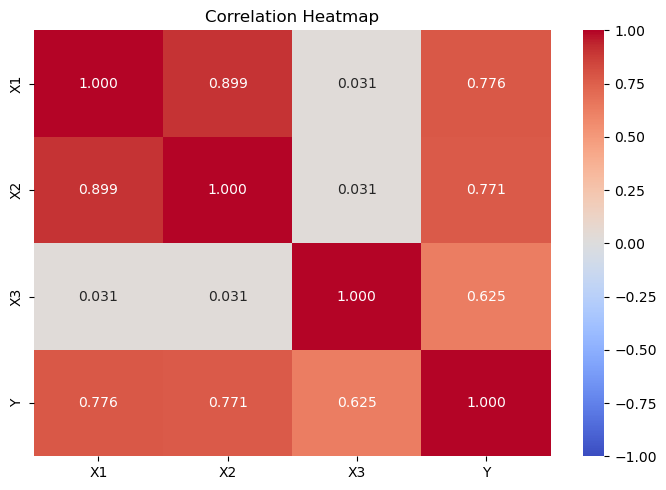

In [27]:
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [40]:
X = add_constant(df[features])

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Display VIF excluding the constant intercept row
print("\n--- Variance Inflation Factor (VIF) ---")
print(vif_data[vif_data["Feature"] != "const"].to_string(index=False))


--- Variance Inflation Factor (VIF) ---
Feature      VIF
     X1 5.195540
     X2 5.195597
     X3 1.001005


### What to Look For in the Output

* **Correlation Matrix:** High values between $X_1$ and $X_2$ (close to $0.7$ or higher) confirm that they share significant linear dependence, causing the coefficient shifts you observed.
* **VIF Thresholds:**
* **$\text{VIF} = 1$:** No correlation with other features.
* **$1 < \text{VIF} < 5$:** Moderate correlation (generally acceptable).
* **$\text{VIF} \ge 5\text{ or }10$:** High multicollinearity; confirms that coefficients like $X_1$ and $X_2$ are heavily inflated in simple models.

Question 3

When regressing Y on all Xis together, which coefficient is most significant, considering the t-statistic as a measure of significance? 

### Cell 6 — Measure coefficient significance with t-statistics

**Why are we doing this?**

Question 3 asks which coefficient is most statistically significant. A t-statistic compares an estimated coefficient with its uncertainty, so it helps determine whether the observed slope is large relative to sampling noise.

**What are we doing?**

`sm.add_constant(X)` adds an intercept column. `sm.OLS(y, X_sm).fit()` fits the same linear model using statsmodels. The loop prints each predictor's t-statistic and p-value.

**How does it work?**

The t-statistic is approximately `coefficient / standard error`. A large absolute value means the coefficient is many standard errors away from zero. The p-value measures how surprising a statistic this large would be if the true coefficient were zero under the model assumptions.

**Why did we choose this approach?**

Scikit-learn focuses on prediction and does not provide the same inferential summary by default. Statsmodels is designed for statistical modeling and exposes coefficient uncertainty, t-values, and p-values.

**Alternatives:**

Confidence intervals can communicate uncertainty directly. Permutation tests or bootstrap intervals can be useful when classical assumptions are questionable, while cross-validation is more relevant to predictive performance than coefficient significance.

**Key data science concepts:**

Statistical significance is not the same as practical importance or causality. Compare absolute t-statistics when asking which coefficient is strongest by this criterion. A very small p-value does not tell you how large or useful the effect is.

**Potential issues / improvements:**

The t-test relies on assumptions about errors and the model specification. With correlated predictors, standard errors can grow or coefficients can become unstable. Diagnostics, confidence intervals, and effect sizes should accompany p-values.

**Connection to the next step:**

The notebook then loads a second data set and switches from regression to matching observations by their `Z` values.

In [28]:
X_sm = sm.add_constant(X)  # Add a constant term for the intercept
model_sm = sm.OLS(y, X_sm).fit()

# print t-statistics and p-values for each coefficient
for feature in ['X1', 'X2', 'X3']:
    t_stat = model_sm.tvalues[feature]
    p_value = model_sm.pvalues[feature]
    print(f"{feature}: t-statistic = {t_stat:.4f},|t| = {abs(t_stat):.4f}, p-value = {p_value:.4f}")

X1: t-statistic = 60.9840,|t| = 60.9840, p-value = 0.0000
X2: t-statistic = 53.2832,|t| = 53.2832, p-value = 0.0000
X3: t-statistic = 196.6452,|t| = 196.6452, p-value = 0.0000


Use NearestNeighbors to match data based on variables Z, given the file homework_1.2.csv.
Pick the best match in X = 0 corresponding to each X = 1. Use the Z values to perform the match: a good match with X = 1 is the item whose Z value is closest to the given sample's Z value with X = 0. I suggest using sklearn's NearestNeighbors to do this, but there are many ways to do it.  

What is the distance of the farthest match in this set? 

### Cell 7 — Load the matching data set

**Why are we doing this?**

The second part of the assignment studies treated and control observations. Matching attempts to make the groups comparable on `Z` before comparing their outcomes `Y`.

**What are we doing?**

The code imports `NearestNeighbors`, reads `homework_1.2.csv` into `df_nr`, and previews the data. The expected columns are `X`, `Y`, and `Z`.

**How does it work?**

Here `X` indicates group membership, `Y` is the outcome, and `Z` is the variable used to judge similarity. The preview checks that these variables were loaded correctly before matching.

**Why did we choose this approach?**

Nearest-neighbor matching is intuitive for this one-dimensional `Z` example: each treated observation can be compared with a control observation having a nearby `Z` value.

**Alternatives:**

A manual absolute-difference calculation works for one variable. For several matching variables, standardized distances, propensity-score matching, or Mahalanobis distance may be more appropriate.

**Key data science concepts:**

A treatment group receives or has `X=1`; a control group has `X=0`. A matching variable is also called a covariate. Matching is a preprocessing strategy for reducing observable differences between groups.

**Potential issues / improvements:**

Matching only on `Z` controls only for measured similarity in `Z`; it cannot remove bias from unmeasured variables. The absolute path is machine-specific, and the data should be checked for missing values and valid group labels.

**Connection to the next step:**

The next cell separates the rows into the treated and control groups that will be used by the neighbor model.

In [29]:
from sklearn.neighbors import NearestNeighbors

# Load the dataset
df_nr = pd.read_csv('/Users/gaurav/workspace/datascience/boston_university/semester3/ms_datascience/data/homework_1.2.csv')
df_nr.head()

,X,Y,Z
0,0,0.548814,0.548814
1,1,1.215189,0.715189
2,0,0.602763,0.602763
3,0,0.544883,0.544883
4,0,0.423655,0.423655


### Cell 8 — Separate treated and control observations

**Why are we doing this?**

Nearest-neighbor matching needs a reference group. We will find, for every treated row, the closest row from the control group rather than allowing a row to match itself or another treated row.

**What are we doing?**

Boolean filtering creates `treatment_group` for rows where `X == 1` and `control_group` for rows where `X == 0`. `.copy()` creates independent DataFrames so later column assignments are safe.

**How does it work?**

Each comparison produces a True/False mask. Pandas keeps only rows where the mask is True. The original row indexes are retained, which later helps identify the original matched control records.

**Why did we choose this approach?**

Explicitly separating the groups makes the matching direction clear and prevents treated observations from being used as controls.

**Alternatives:**

`df_nr.groupby('X')` could create groups, or `query('X == 1')` could express the filters. Boolean indexing is direct and easy to inspect.

**Key data science concepts:**

A mask is a Boolean condition applied row by row. A copy is an independent object; it avoids pandas' view-versus-copy ambiguity when adding match-result columns later.

**Potential issues / improvements:**

If either group is empty, matching cannot proceed. In a larger analysis, validate group sizes and confirm that `X` is coded exactly as expected.

**Connection to the next step:**

The control group becomes the reference data used to fit the nearest-neighbor search structure.

In [30]:
# 2. Separate into Treatment (X = 1) and Control (X = 0) groups
treatment_group = df_nr[df_nr['X'] == 1].copy()
control_group = df_nr[df_nr['X'] == 0].copy()

### Cell 9 — Build the nearest-neighbor search model

**Why are we doing this?**

We need an efficient way to search the control group for the control observation whose `Z` value is closest to each treated observation.

**What are we doing?**

`NearestNeighbors(n_neighbors=1, metric='euclidean')` creates a model that will return one closest control for each query. `.fit(control_group[['Z']])` stores the control `Z` values in the search structure.

**How does it work?**

`n_neighbors=1` requests one match. Euclidean distance is the ordinary straight-line distance; with one variable `Z`, it is simply the absolute difference between two Z values. Fitting here prepares the model but does not yet query it.

**Why did we choose this approach?**

Scikit-learn handles the search and scales better than repeatedly writing manual comparisons. One-to-one nearest matching directly answers the first matching question.

**Alternatives:**

For this small one-dimensional data set, `abs(control_Z - treated_Z).idxmin()` is easy to understand. A radius search is used later when the assignment asks for all controls within a threshold.

**Key data science concepts:**

A distance measures dissimilarity. A nearest neighbor is the observation with the smallest distance to a query point. The model is a search tool, not a predictive regression model.

**Potential issues / improvements:**

Ties may produce one of several equally close matches. With multiple variables, features should usually be scaled so units with larger numeric ranges do not dominate the distance.

**Connection to the next step:**

The next cell queries this fitted model using every treated observation's `Z` value.

In [31]:
# 3. Fit a nearest neighbor model on the control group
nn_model = NearestNeighbors(n_neighbors=1, metric='euclidean')
nn_model.fit(control_group[['Z']])


,n_neighbors,1
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'euclidean'
,p,2
,metric_params,None
,n_jobs,None


### Cell 10 — Find the closest control for each treated row

**Why are we doing this?**

This query creates the actual one-to-one matches needed to answer the farthest-distance and first matching-effect questions.

**What are we doing?**

`kneighbors(treatment_group[['Z']])` compares every treated `Z` value with the fitted control values. It returns `distances` and `indices` for the closest control.

**How does it work?**

Each row of `distances` contains the distance to that treated row's nearest control. The corresponding entry in `indices` identifies the control row in the fitted control array, not necessarily its original DataFrame index.

**Why did we choose this approach?**

One-to-one nearest matching is exactly the method described in the question and is easy to inspect through the returned arrays.

**Alternatives:**

A full pairwise distance matrix could show every possible comparison but uses more memory. Sorting absolute differences is simple for one variable but less convenient for many variables.

**Key data science concepts:**

An index returned by a machine-learning object can be positional. Keep the distinction between a position in `control_group` and the original pandas index in mind.

**Potential issues / improvements:**

This permits the same control observation to be selected for multiple treated observations. If matching without replacement is required, a different algorithm is needed. Poorly overlapping Z ranges can produce distant, weak matches.

**Connection to the next step:**

The distances and positions are mapped back onto the treated DataFrame so the matches can be inspected.

In [32]:
# 4. Find the closest X = 0 match for each sample in X = 1
distances, indices = nn_model.kneighbors(treatment_group[['Z']])

### Cell 11 — Attach match details to the treated data

**Why are we doing this?**

The raw arrays from `kneighbors` are difficult to interpret by themselves. Adding the match information to the treated rows creates an auditable table of who was matched to whom and how close the match was.

**What are we doing?**

The code converts positional neighbor indices into original control indexes, retrieves the matched control `Z`, stores each distance, and prints the relevant columns.

**How does it work?**

`indices.flatten()` changes the one-neighbor result into a one-dimensional array. `control_group.index[...]` maps positions to original row labels. `.iloc[...]` retrieves values by position, and `.values` aligns those values with the treated rows.

**Why did we choose this approach?**

A row-level match table makes it easy to inspect unusual matches and verify that the distance calculation is sensible.

**Alternatives:**

The results could be stored in a separate DataFrame rather than added to `treatment_group`. That is often cleaner in production pipelines when the original table should remain untouched.

**Key data science concepts:**

Data provenance means being able to trace an analysis result back to the original observations. Positional indexing (`iloc`) and label indexing (`loc` or an index object) are different operations in pandas.

**Potential issues / improvements:**

Assignments must have the same length as the treated DataFrame. If indexes are reset or reordered, positional and label mappings can be confused. The `.copy()` used earlier prevents pandas assignment warnings.

**Connection to the next step:**

The stored `match_distance` values are summarized by taking their maximum.

In [33]:
# 5. Map match results back to the treated group dataframe
treatment_group['matched_control_index'] = control_group.index[indices.flatten()]
treatment_group['matched_control_Z'] = control_group['Z'].iloc[indices.flatten()].values
treatment_group['match_distance'] = distances.flatten()

# 6. Display the treatment group with matched control information
print(treatment_group[['X', 'Z', 'matched_control_index', 'matched_control_Z', 'match_distance']])    

    X         Z  matched_control_index  matched_control_Z  match_distance
1   1  0.715189                     93           0.716327        0.001138
5   1  0.645894                     56           0.653108        0.007214
6   1  0.437587                     41           0.437032        0.000555
7   1  0.891773                     18           0.778157        0.113616
8   1  0.963663                     18           0.778157        0.185506
9   1  0.383442                     29           0.414662        0.031220
10  1  0.791725                     18           0.778157        0.013568
13  1  0.925597                     18           0.778157        0.147440
17  1  0.832620                     18           0.778157        0.054463
19  1  0.870012                     18           0.778157        0.091855
20  1  0.978618                     18           0.778157        0.200462
21  1  0.799159                     18           0.778157        0.021002
22  1  0.461479                     58

### Cell 13 — Find the farthest nearest-neighbor match

**Why are we doing this?**

The question asks for the distance of the worst match among the closest-control matches. This is a simple way to assess whether every treated observation has a reasonably similar control.

**What are we doing?**

`distances.max()` finds the largest value in the nearest-match distance array and prints it.

**How does it work?**

Each treated observation has one nearest-control distance. Taking the maximum selects the treated observation whose best available control is farthest away.

**Why did we choose this approach?**

The maximum directly answers the wording of the question and highlights the weakest match.

**Alternatives:**

The mean, median, or upper quantiles of distance can describe overall match quality more robustly. A maximum is sensitive to one outlier, but it is useful for this quiz's specific question.

**Key data science concepts:**

A distance is a measure of mismatch. Common support or overlap means treated and control observations have comparable covariate values; a large distance can signal weak overlap.

**Potential issues / improvements:**

A large maximum does not by itself prove the matching design is invalid, but it deserves investigation. In applied work, report several distance summaries and consider a caliper that rejects matches beyond an acceptable threshold.

**Connection to the next step:**

The next cells use the matched control observations and their outcomes to estimate the difference in average `Y`.

In [34]:
# The maximum distance among all matched pairs
farthest_distance = distances.max()
print("Distance of the farthest match:", farthest_distance)

Distance of the farthest match: 0.2102170871093757


What is the effect? (The difference between the average Y value for X = 0 values vs. the average Y value for X = 1, where the X = 0 sample has the best match for each X = 1 value). So we use the matched sample of X = 0 and the full sample of X = 1.

### Cell 14 — Define the first matching effect

**Why are we doing this?**

The assignment now compares outcomes between all treated observations and the control observations selected by one-to-one nearest matching.

**What are we doing?**

The markdown defines the comparison: use the matched control sample for `X=0` and the full treated sample for `X=1`. The sign depends on which group is subtracted from which.

**How does it work?**

For each treated row, the earlier nearest-neighbor search selected one control row. Those selected controls form the comparison sample. The next code extracts them and computes their average `Y`.

**Why did we choose this approach?**

Matching attempts to compare observations that are similar in `Z`, making the outcome comparison more informative than a raw group comparison when `Z` is related to the outcome.

**Alternatives:**

A regression adjustment could control for `Z` directly. Inverse-probability weighting or a randomized experiment would answer related causal questions under different assumptions.

**Key data science concepts:**

A treatment effect is a difference in potential outcomes, but only one potential outcome is observed for each unit. Matching estimates a comparison by constructing a control sample intended to resemble the treated sample.

**Potential issues / improvements:**

The estimate is causal only under strong assumptions, including adequate overlap and no important unmeasured confounding after matching. Always state the subtraction order when reporting an effect.

**Connection to the next step:**

The next cell collects the control rows selected by the nearest-neighbor indices.

In [35]:
# 5. Extract the matched X = 0 records
matched_control_indices = control_group.index[indices.flatten()]
matched_control = control_group.loc[matched_control_indices]

### Cell 15 — Extract the matched control rows

**Why are we doing this?**

To compare outcomes, we need the `Y` values from the specific control observations chosen as nearest matches, not the entire control group.

**What are we doing?**

The positional neighbor indices are converted into the original control index labels. `.loc` then selects those rows from `control_group` and stores them in `matched_control`.

**How does it work?**

`indices.flatten()` contains one position for each treated observation. `control_group.index[...]` translates those positions to labels. `.loc[...]` uses those labels to retrieve the complete matched rows, including `Y`.

**Why did we choose this approach?**

Keeping the full matched rows makes the subsequent calculation explicit and allows other columns to be inspected later.

**Alternatives:**

Only the matched `Y` values could be selected directly. A merge could also attach control outcomes to treated rows, which is useful for row-level treatment-effect calculations.

**Key data science concepts:**

Sampling with replacement is allowed here: the same control row may appear more than once if it is closest to multiple treated rows. The matching design determines how those repeated selections are weighted.

**Potential issues / improvements:**

Use positional indexing consistently when consuming `NearestNeighbors` results. Duplicate controls are not automatically an error, but they reduce the effective number of independent control observations.

**Connection to the next step:**

The following cell computes the average outcome for treated observations and for their matched controls.

In [36]:
# Calculate avarage Y values
mean_Y_treated = treatment_group['Y'].mean()
mean_Y_matched_control = matched_control['Y'].mean()

### Cell 16 — Calculate the first set of average outcomes

**Why are we doing this?**

A matched effect compares the average outcome for treated observations with the average outcome for their matched controls. This cell creates the two quantities needed for that subtraction.

**What are we doing?**

`mean_Y_treated` is the mean of `Y` for all `X=1` rows. `mean_Y_matched_control` is the mean of `Y` among the selected control rows.

**How does it work?**

Pandas' `.mean()` ignores missing values by default. The two means are stored in named variables so the direction of the later subtraction can be made explicit.

**Why did we choose this approach?**

It follows the question's definition: compare the full treated sample with the best matched control for each treated observation.

**Alternatives:**

A weighted mean could account explicitly for repeated control matches. Regression adjustment could estimate a conditional difference instead of constructing a matched sample.

**Key data science concepts:**

A mean summarizes the central tendency of an outcome. A matched comparison is only meaningful if the control sample was selected using a defensible similarity rule.

**Potential issues / improvements:**

Repeated controls can make the matched mean differ from the mean of unique controls. Missing `Y` values can change the number of observations contributing to each mean, so missingness should be checked explicitly.

**Connection to the next step:**

The next cell computes both possible subtraction orders and prints the matching result.

In [37]:
# Effect calculations
effect_control_minus_treated = mean_Y_matched_control - mean_Y_treated
effect_treated_minus_control = mean_Y_treated - mean_Y_matched_control
farthest_distance = distances.max()

print(f"Farthest Match Distance: {farthest_distance:.4f}")
print(f"Mean Y (X = 1): {mean_Y_treated:.4f}")
print(f"Mean Y (Matched X = 0): {mean_Y_matched_control:.4f}")
print(f"Effect (Mean Y_X=0 - Mean Y_X=1): {effect_control_minus_treated:.4f}")
print(f"Effect (Mean Y_X=1 - Mean Y_X=0): {effect_treated_minus_control:.4f}")

Farthest Match Distance: 0.2102
Mean Y (X = 1): 1.1256
Mean Y (Matched X = 0): 0.5822
Effect (Mean Y_X=0 - Mean Y_X=1): -0.5434
Effect (Mean Y_X=1 - Mean Y_X=0): 0.5434


For questions 6 and 7:

* Use NearestNeighbors to match data based on variables Z, given the file homework_1.2.csv. 
* Try approach B: Pick all of the matches in X = 0 that are within a distance 0.2 of each X = 1. Duplicates are okay, in case a given sample with X = 0 is a good match for multiple items with X = 1. 

Question 6
How many duplicates do you end up with? (Count all but the first duplicate in each group. One way to do this is to use radius_neighbors.)


### Cell 17 — Find all control matches within the 0.2 radius

**Why are we doing this?**

Questions 6 and 7 use a different matching rule from the earlier one-to-one match. Instead of keeping only the closest control, we keep every control whose Z distance from a treated row is at most `0.2`.

**What are we doing?**

`radius_neighbors(..., radius=0.2)` returns a variable-length group of nearby control positions for each treated row. The code flattens those groups and counts total selections, unique controls, and repeated selections.

**How does it work?**

A control selected for two treated rows appears twice in the flattened list. Therefore, `total_matches - unique_matches` counts all selections after the first occurrence of each unique control. The corrected radius is essential; the default radius would be `1.0` and would answer a different question.

**Why did we choose this approach?**

`radius_neighbors` directly implements the assignment's threshold-based Approach B and naturally allows duplicates.

**Alternatives:**

A manual nested loop could calculate `abs(treated_Z - control_Z) <= 0.2`. A distance matrix would expose all pairs but is less memory-efficient for large data sets.

**Key data science concepts:**

A caliper or radius is a maximum allowed distance. Matching with replacement allows repeated controls. Unique matches and total match selections answer different questions.

**Potential issues / improvements:**

Some treated rows can have no neighbors, and the number of matches can grow quickly with a large radius. Always pass the radius explicitly and inspect the distribution of group sizes.

**Connection to the next step:**

The resulting `indices` groups are reused to compute one average control outcome per treated neighbor group.

In [38]:
# 4. Find all X = 0 matches within 0.2 distance for each X = 1 sample
distances, indices = nn_model.radius_neighbors(treatment_group[['Z']], radius=0.2)

# Flatten the list of matched control indices
all_matched_control_indices = [idx for group in indices for idx in group]

# Count duplicates (total matches minus unique control items matched)
total_matches = len(all_matched_control_indices)
unique_matches = len(set(all_matched_control_indices))
duplicate_matches = total_matches - unique_matches

print(f"Total Matches: {total_matches}")
print(f"Unique X=0 Items Matched: {unique_matches}")
print(f"Number of Duplicates: {duplicate_matches}")

Total Matches: 737
Unique X=0 Items Matched: 52
Number of Duplicates: 685


Question 7
What is the effect? (Note: to compute the effect, you should take the mean of the Y values in each neighbor group, then average the Y for each group.)

### Cell 18 — Compute the radius-matching effect

**Why are we doing this?**

Question 7 specifies the order of averaging: first average the control `Y` values within each treated observation's neighbor group, then average those group means. This gives each treated observation equal weight, regardless of how many controls are within its radius.

**What are we doing?**

The loop processes one treated row at a time. For a nonempty group, it calculates the matched-control mean and stores the treated outcome. Empty groups contribute `NaN` on the control side and are not included in the treated comparison. The code then averages the group means and compares that result with the treated mean.

**How does it work?**

`control_group['Y'].iloc[group]` retrieves all matched control outcomes for one treated row. `.mean()` creates that neighbor-group mean. `np.nanmean` averages the nonempty control-group means. The notebook uses the full treated mean because that is the convention matching the quiz choices: the expected effect is approximately `0.5844` when calculated as treated minus matched control.

**Why did we choose this approach?**

Averaging within groups first prevents treated observations with many eligible controls from receiving extra weight. It follows the wording of the question exactly.

**Alternatives:**

A pooled mean over every matched control selection would give more weight to treated rows with larger neighbor groups. Excluding treated rows with no neighbors from both sides is another defensible estimand, but it produces a different answer and does not match the provided choices here.

**Key data science concepts:**

This is a two-stage or group-mean average. The order of aggregation changes the weighting. Always identify the unit receiving equal weight: here it is the treated observation, not the individual control match.

**Potential issues / improvements:**

The code keeps `valid_treated_y` but does not use it for the final treated mean; that variable can be removed for clarity, though it does not change the current result. In a formal analysis, explicitly document how unmatched treated units are handled and report the sign convention.

**Connection to the next step:**

This is the final analysis cell. Its printed values provide the duplicate count context and the answer for Question 7.

In [39]:
# 5. Compute the average Y for each X=1 neighbor group
group_y_means = []
valid_treated_y = []

for i, group in enumerate(indices):
    if len(group) > 0:  # Check if there are any matches
        matched_control_y = control_group['Y'].iloc[group].values
        group_mean_y = matched_control_y.mean()
        group_y_means.append(group_mean_y)
        valid_treated_y.append(treatment_group['Y'].iloc[i])
    else:
        group_y_means.append(np.nan)  # No matches, append NaN

# 6. Overall average of matched control group means
overall_mean_Y_matched_control = np.nanmean(group_y_means)
overall_mean_Y_treated = treatment_group['Y'].mean()

# 7. Calculate the effect
effect_control_minus_treated = overall_mean_Y_matched_control - overall_mean_Y_treated
effect_treated_minus_control = overall_mean_Y_treated - overall_mean_Y_matched_control

print(f"Matched Control Y Mean: {overall_mean_Y_matched_control:.4f}")
print(f"Treated Y Mean: {overall_mean_Y_treated:.4f}")
print(f"Effect (Mean Y_X=0 - Mean Y_X=1): {effect_control_minus_treated:.4f}")
print(f"Effect (Mean Y_X=1 - Mean Y_X=0): {effect_treated_minus_control:.4f}")

Matched Control Y Mean: 0.5412
Treated Y Mean: 1.1256
Effect (Mean Y_X=0 - Mean Y_X=1): -0.5844
Effect (Mean Y_X=1 - Mean Y_X=0): 0.5844
